In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.metrics import accuracy_score , classification_report
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier , VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv("novagen_dataset.csv")
df.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  Phys

In [4]:
df.isnull().sum()

Age                      0
BMI                      0
Blood_Pressure           0
Cholesterol              0
Glucose_Level            0
Heart_Rate               0
Sleep_Hours              0
Exercise_Hours           0
Water_Intake             0
Stress_Level             0
Target                   0
Smoking                  0
Alcohol                  0
Diet                     0
MentalHealth             0
PhysicalActivity         0
MedicalHistory           0
Allergies                0
Diet_Type__Vegan         0
Diet_Type__Vegetarian    0
Blood_Group_AB           0
Blood_Group_B            0
Blood_Group_O            0
dtype: int64

In [5]:
x = df.drop(columns=["Target"])
y = df["Target"]

In [6]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42 , stratify=y)

# Model 1 - Decision Tree

In [7]:
dt = DecisionTreeClassifier()

dt.fit(x_train , y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [8]:
y_pred = dt.predict(x_test)

print("Accuracy Score : ", accuracy_score(y_test , y_pred))
print("Classification Report : \n", classification_report(y_test , y_pred))

Accuracy Score :  0.8905759162303665
Classification Report : 
               precision    recall  f1-score   support

           0       0.90      0.87      0.88       914
           1       0.88      0.91      0.90       996

    accuracy                           0.89      1910
   macro avg       0.89      0.89      0.89      1910
weighted avg       0.89      0.89      0.89      1910



In [9]:
y_pred_train = dt.predict(x_train)

print("Accuracy Score : ", accuracy_score(y_train , y_pred_train))

Accuracy Score :  1.0


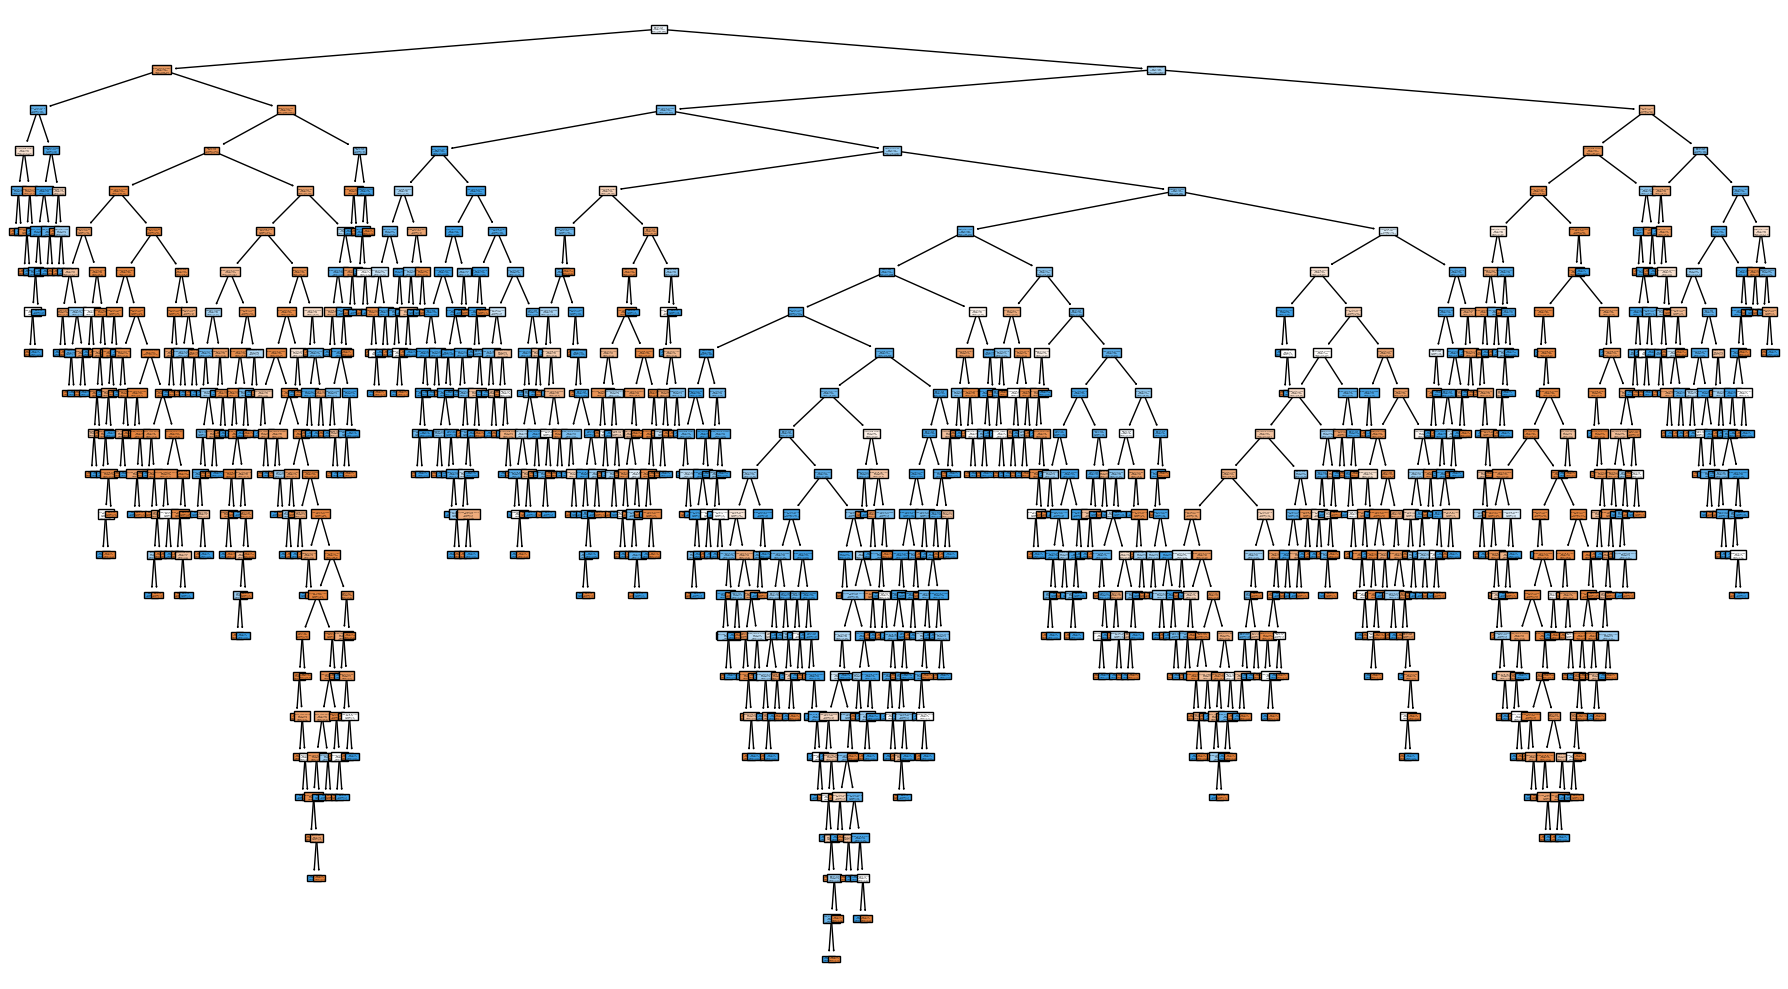

In [13]:
plt.figure(figsize=(18 , 10))

plot_tree(
    dt,
    feature_names=x.columns,
    class_names=["Healthy" , "Unhealthy"],
    filled=True
)

plt.tight_layout()

# Model 2 - Random Forest

In [16]:
rf = RandomForestClassifier()

In [17]:
param_grid = {
    'n_estimators': [100 , 150 , 200 , 300],
    'max_depth': [None , 10 , 20 , 30],
    'min_samples_split': [2 , 5 , 10],
    'min_samples_leaf': [1 , 2 , 4],
    'max_features': ['sqrt' , 'log2'],
    'bootstrap': [True]
}

gridcv = GridSearchCV(
    rf,
    param_grid,
    scoring="accuracy",
    n_jobs=-1,
    cv=5
)

gridcv.fit(x_train , y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'bootstrap': [True], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,150


In [18]:
gridcv.best_params_

{'bootstrap': True,
 'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 150}

In [19]:
best_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=2,
    bootstrap=True,
    random_state=42
)

best_model.fit(x_train , y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
y_pred = best_model.predict(x_test)
y_pred_train = best_model.predict(x_train)

print("Training Accuracy : ", accuracy_score(y_train , y_pred_train))
print("Testing Accuracy : ", accuracy_score(y_test , y_pred))
print("Classification Report : \n", classification_report(y_test , y_pred))

Training Accuracy :  1.0
Testing Accuracy :  0.9382198952879581
Classification Report : 
               precision    recall  f1-score   support

           0       0.95      0.92      0.93       914
           1       0.93      0.96      0.94       996

    accuracy                           0.94      1910
   macro avg       0.94      0.94      0.94      1910
weighted avg       0.94      0.94      0.94      1910



# Model 3 - KNN

In [23]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(x_train , y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [24]:
y_pred = knn.predict(x_test)
y_pred_train = knn.predict(x_train)

print("Training Accuracy : ", accuracy_score(y_train , y_pred_train))
print("Testing Accuracy : ", accuracy_score(y_test , y_pred))
print("Classification Report : \n", classification_report(y_test , y_pred))

Training Accuracy :  0.9249901819609897
Testing Accuracy :  0.887434554973822
Classification Report : 
               precision    recall  f1-score   support

           0       0.89      0.87      0.88       914
           1       0.89      0.90      0.89       996

    accuracy                           0.89      1910
   macro avg       0.89      0.89      0.89      1910
weighted avg       0.89      0.89      0.89      1910



# Model 4 - Gradient Boosting

In [25]:
gbc = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbc.fit(x_train , y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,150
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [26]:
y_pred = gbc.predict(x_test)
y_pred_train = gbc.predict(x_train)

print("Training Accuracy : ", accuracy_score(y_train , y_pred_train))
print("Testing Accuracy : ", accuracy_score(y_test , y_pred))
print("Classification Report : \n", classification_report(y_test , y_pred))

Training Accuracy :  0.9358554784657678
Testing Accuracy :  0.9303664921465968
Classification Report : 
               precision    recall  f1-score   support

           0       0.94      0.91      0.93       914
           1       0.92      0.95      0.93       996

    accuracy                           0.93      1910
   macro avg       0.93      0.93      0.93      1910
weighted avg       0.93      0.93      0.93      1910



# Model 5 - Logistic Regression

In [29]:
lr = LogisticRegression(max_iter=1000 , penalty="l2" , solver="liblinear" , random_state=42)

lr.fit(x_train , y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [30]:
y_pred = lr.predict(x_test)
y_pred_train = lr.predict(x_train)

print("Training Accuracy : ", accuracy_score(y_train , y_pred_train))
print("Testing Accuracy : ", accuracy_score(y_test , y_pred))
print("Classification Report : \n", classification_report(y_test , y_pred))

Training Accuracy :  0.784395863332897
Testing Accuracy :  0.775392670157068
Classification Report : 
               precision    recall  f1-score   support

           0       0.77      0.76      0.76       914
           1       0.78      0.79      0.79       996

    accuracy                           0.78      1910
   macro avg       0.78      0.77      0.77      1910
weighted avg       0.78      0.78      0.78      1910



# Model 6 - Voting Classifier

In [31]:
vc = VotingClassifier(
    estimators=[
        ("lr" , LogisticRegression(max_iter=1000 , solver="liblinear")),
        ("knn" , KNeighborsClassifier(n_neighbors=5)),
        ("rf" , RandomForestClassifier(n_estimators=200 , random_state=42)),
    ],
    voting="soft"
)

vc.fit(x_train , y_train)

,estimators,"[('lr', ...), ('knn', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [32]:
y_pred = vc.predict(x_test)
y_pred_train = vc.predict(x_train)

print("Training Accuracy : ", accuracy_score(y_train , y_pred_train))
print("Testing Accuracy : ", accuracy_score(y_test , y_pred))
print("Classification Report : \n", classification_report(y_test , y_pred))

Training Accuracy :  0.9642623380023563
Testing Accuracy :  0.9057591623036649
Classification Report : 
               precision    recall  f1-score   support

           0       0.91      0.89      0.90       914
           1       0.90      0.92      0.91       996

    accuracy                           0.91      1910
   macro avg       0.91      0.91      0.91      1910
weighted avg       0.91      0.91      0.91      1910



# Here, the best model is RandomForestClassifier.